# Alzheimer MRI Classification using ResNet50
Train / Validation split from train folder, augmentation, evaluation and prediction.

In [1]:
# ===============================
# 1 Import Libraries
# ===============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.10.0


In [2]:
# ===============================
# 2 GPU Configuration
# ===============================

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPUs:", gpus)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ===============================
# 3 Paths and Parameters
# ===============================

TRAIN_DIR = "Alzheimer_Dataset/train"
TEST_DIR = "Alzheimer_Dataset/test"
VAL_DIR   = "Alzheimer_Dataset/val"

IMG_SIZE = (176,176)
BATCH_SIZE = 32
SEED = 42

CLASSES = [
'NonDemented',
'VeryMildDemented',
'MildDemented',
'ModerateDemented'
]


In [4]:
# ===============================
# 4 Load Train Dataset
# ===============================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    class_names=CLASSES, # Remember to keep this from our previous fix!
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 4480 files belonging to 4 classes.


In [5]:
# ===============================
# 5 Validation Dataset
# ===============================

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 960 files belonging to 4 classes.


In [6]:
# ===============================
# 6 Test Dataset
# ===============================

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # Crucial: Never shuffle the test set so your confusion matrix lines up
)

Found 960 files belonging to 4 classes.


In [7]:
# ===============================
# 7 Data Augmentation
# ===============================

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1,0.1),
    layers.GaussianNoise(5.0)
])

def augment(images, labels):
    images = data_augmentation(images)
    return images, labels

train_dataset = train_dataset.map(augment)


In [8]:
# ===============================
# 8 ResNet Preprocessing
# ===============================

def preprocess(images, labels):
    images = preprocess_input(images)
    return images, labels

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)


In [9]:
# ===============================
# 9 Prefetch for performance
# ===============================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)


In [10]:
# ===============================
# 10 Build ResNet Model
# ===============================

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(176,176,3)
)


model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])


In [11]:
# ===============================
# 11 Compile Model
# ===============================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 6, 6, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                

In [12]:
# ===============================
# 12 Training
# ===============================

early_stop = EarlyStopping(
    monitor="val_acc",
    patience=5,
    restore_best_weights=True
)

class_weights = {
0:1.0,
1:1.42,
2:3.57,
3:50.0
}

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop]

)


Epoch 1/50
140/140 [==============================] - 64s 367ms/step - loss: 3.8708 - acc: 0.2922 - auc: 0.5477 - val_loss: 1.3939 - val_acc: 0.4771 - val_auc: 0.6911
Epoch 2/50
140/140 [==============================] - 50s 357ms/step - loss: 2.5519 - acc: 0.3864 - auc: 0.6556 - val_loss: 1.9311 - val_acc: 0.4000 - val_auc: 0.6214
Epoch 3/50
140/140 [==============================] - 50s 359ms/step - loss: 2.0473 - acc: 0.4721 - auc: 0.7286 - val_loss: 1.9500 - val_acc: 0.4042 - val_auc: 0.6349
Epoch 4/50
140/140 [==============================] - 51s 360ms/step - loss: 1.6984 - acc: 0.5373 - auc: 0.7820 - val_loss: 1.7881 - val_acc: 0.4292 - val_auc: 0.6679
Epoch 5/50
140/140 [==============================] - 62s 441ms/step - loss: 1.4036 - acc: 0.5949 - auc: 0.8292 - val_loss: 1.5420 - val_acc: 0.4719 - val_auc: 0.7151
Epoch 6/50
140/140 [==============================] - 69s 490ms/step - loss: 1.1593 - acc: 0.6618 - auc: 0.8719 - val_loss: 1.1706 - val_acc: 0.5521 - val_auc: 0.797

KeyboardInterrupt: 

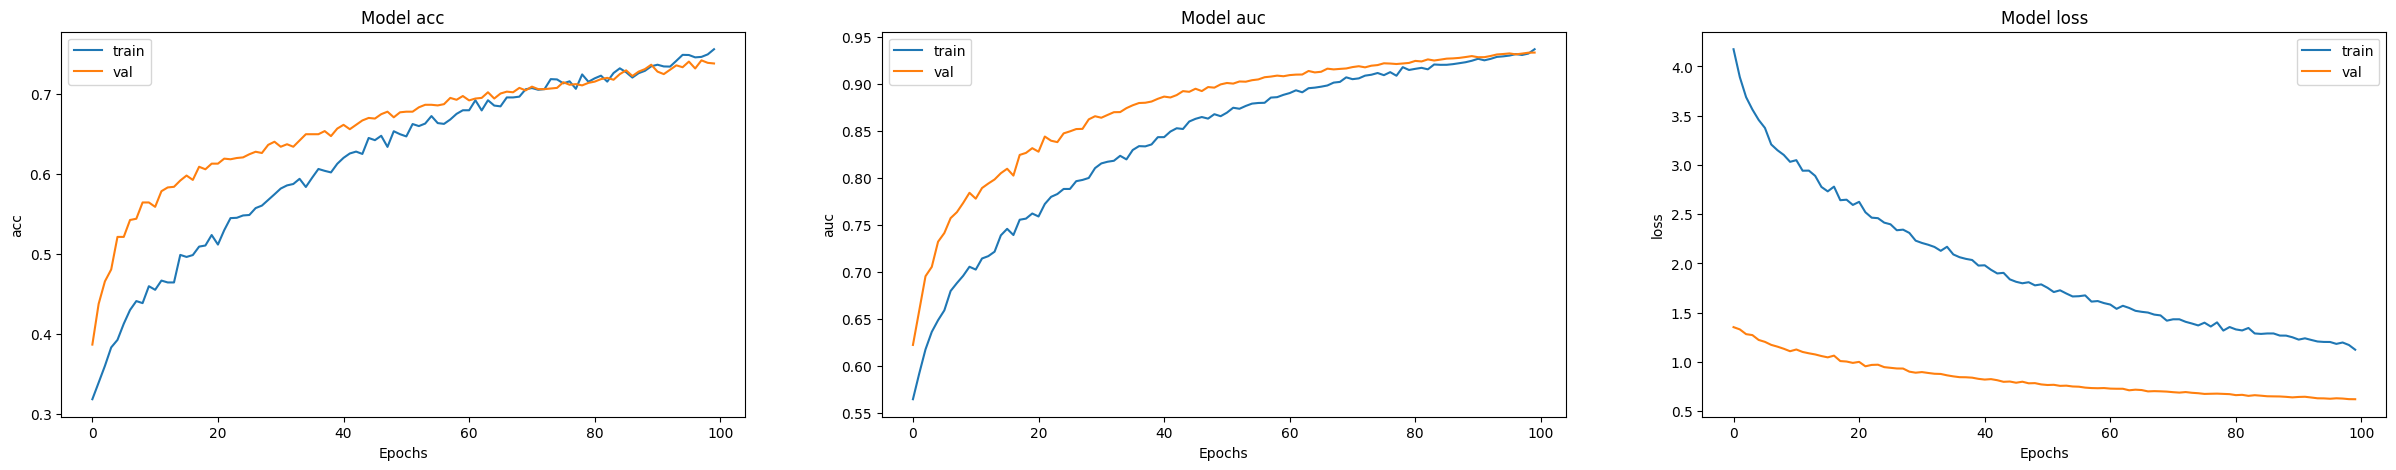

In [38]:
# ===============================
# 13 Plot Training Metrics
# ===============================

fig, ax = plt.subplots(1, 3, figsize = (30, 5))
ax = ax.ravel()

for i, metric in enumerate(["acc", "auc", "loss"]):
    ax[i].plot(history.history[metric])
    ax[i].plot(history.history["val_" + metric])
    ax[i].set_title("Model {}".format(metric))
    ax[i].set_xlabel("Epochs")
    ax[i].set_ylabel(metric)
    ax[i].legend(["train", "val"])

plt.show()


In [39]:
# ===============================
# 14 Evaluate on Test Set
# ===============================

test_scores = model.evaluate(test_dataset)

print('Testing Accuracy: %.2f%%' % (test_scores[1] * 100))


200/200 [==============================] - 18s 89ms/step - loss: 0.4731 - acc: 0.8120 - auc: 0.9625
Testing Accuracy: 81.20%


In [40]:
# ===============================
# 15 Predictions
# ===============================

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())


1/1 [==============================] - 0s 30ms/step


In [41]:
# ===============================
# 16 Classification Report
# ===============================

print(classification_report(y_true, y_pred, target_names=CLASSES))


                  precision    recall  f1-score   support

     NonDemented       0.95      0.38      0.55       896
VeryMildDemented       1.00      0.19      0.32        64
    MildDemented       0.89      0.88      0.89      3200
ModerateDemented       0.71      0.90      0.79      2240

        accuracy                           0.81      6400
       macro avg       0.89      0.59      0.64      6400
    weighted avg       0.83      0.81      0.80      6400



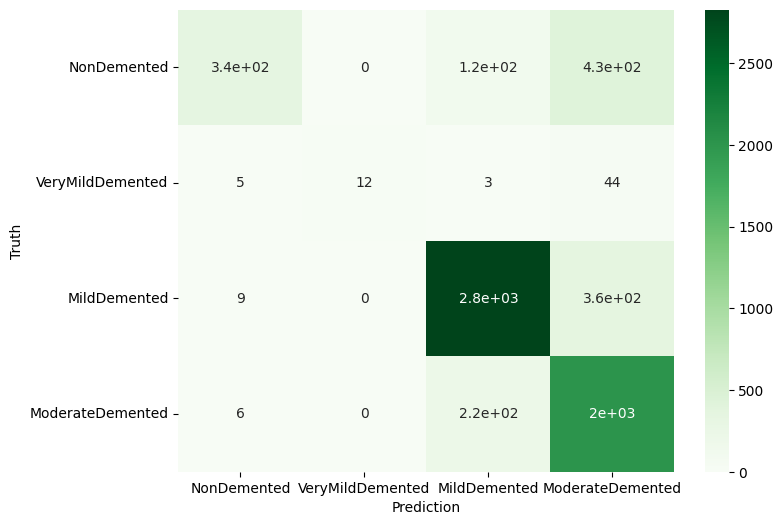

In [42]:
# ===============================
# 17 Confusion Matrix
# ===============================

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Greens",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Prediction")
plt.ylabel("Truth")

plt.show()


In [ ]:
# ===============================
# 18 Save Model
# ===============================

model.save("alzheimer_resnet_model3.keras")
print("Model saved.")


Model saved.
